In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

PARQUET = Path(__file__).resolve().parents[1] / "data_processed/gridmet.parquet" if "__file__" in dir() else Path("../data_processed/gridmet.parquet")

df = pd.read_parquet(PARQUET)
print(df.shape)
print(df.dtypes)
df.head()


(11832132, 18)
time                             datetime64[ns]
lat                                     float64
lon                                     float64
precipitation                           float32
max_temp                                float32
min_temp                                float32
wind_speed                              float32
wind_direction                          float32
solar_radiation                         float32
rh_max                                  float32
rh_min                                  float32
specific_humidity                       float32
vapor_pressure_deficit                  float32
energy_release_component                float32
burning_index                           float32
fuel_moisture_100hr                     float32
palmer_drought_severity_index           float32
actual_evapotranspiration               float32
dtype: object


,time,lat,lon,precipitation,max_temp,min_temp,wind_speed,wind_direction,solar_radiation,rh_max,rh_min,specific_humidity,vapor_pressure_deficit,energy_release_component,burning_index,fuel_moisture_100hr,palmer_drought_severity_index,actual_evapotranspiration
0,2012-01-05,36.983333,-122.183333,0.0,290.600006,279.899994,7.0,330.0,131.300003,87.099998,41.700001,0.00556,0.59,30.0,39.0,16.799999,2.98,4.3
1,2012-01-05,36.983333,-122.141667,0.0,291.600006,279.500000,6.4,330.0,130.600006,85.199997,37.299999,0.00538,0.67,31.0,39.0,16.100000,2.41,4.6
2,2012-01-05,36.983333,-122.100000,0.0,292.200012,279.500000,5.7,337.0,129.800003,83.199997,34.500000,0.00529,0.73,34.0,44.0,15.500000,2.21,4.7
3,2012-01-05,36.983333,-122.058333,0.0,292.600006,279.500000,5.1,337.0,129.100006,80.500000,33.500000,0.00514,0.79,36.0,41.0,14.800000,2.36,4.6
4,2012-01-05,36.983333,-122.016667,0.0,292.799988,280.000000,4.5,337.0,127.000000,76.300003,32.500000,0.00505,0.82,39.0,41.0,13.800000,2.40,4.5


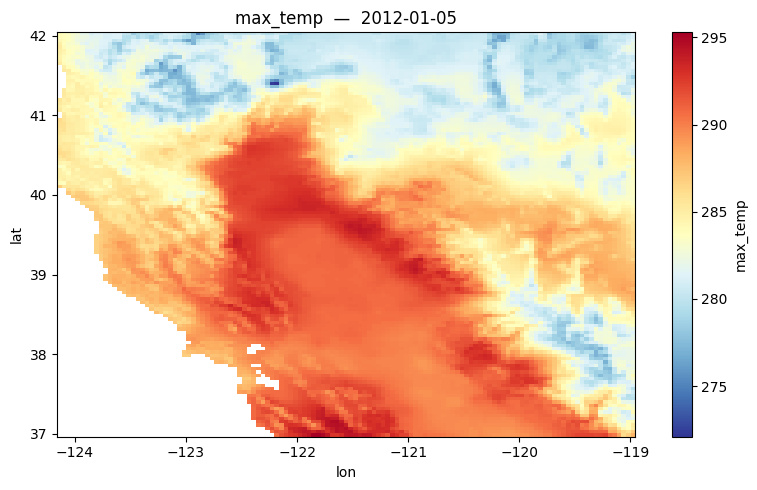

In [ ]:
# Spatial snapshot — one variable on one day
import matplotlib.pyplot as plt

VAR = "max_temp"   # change to any column name
DATE = df["time"].min()

snap = df[df["time"] == DATE].pivot(index="lat", columns="lon", values=VAR)

fig, ax = plt.subplots(figsize=(8, 5))
im = ax.pcolormesh(snap.columns, snap.index, snap.values, cmap="RdYlBu_r")
plt.colorbar(im, ax=ax, label=VAR)
ax.set_title(f"{VAR}  —  {DATE.date()}")
ax.set_xlabel("lon")
ax.set_ylabel("lat")
plt.tight_layout()
plt.show()


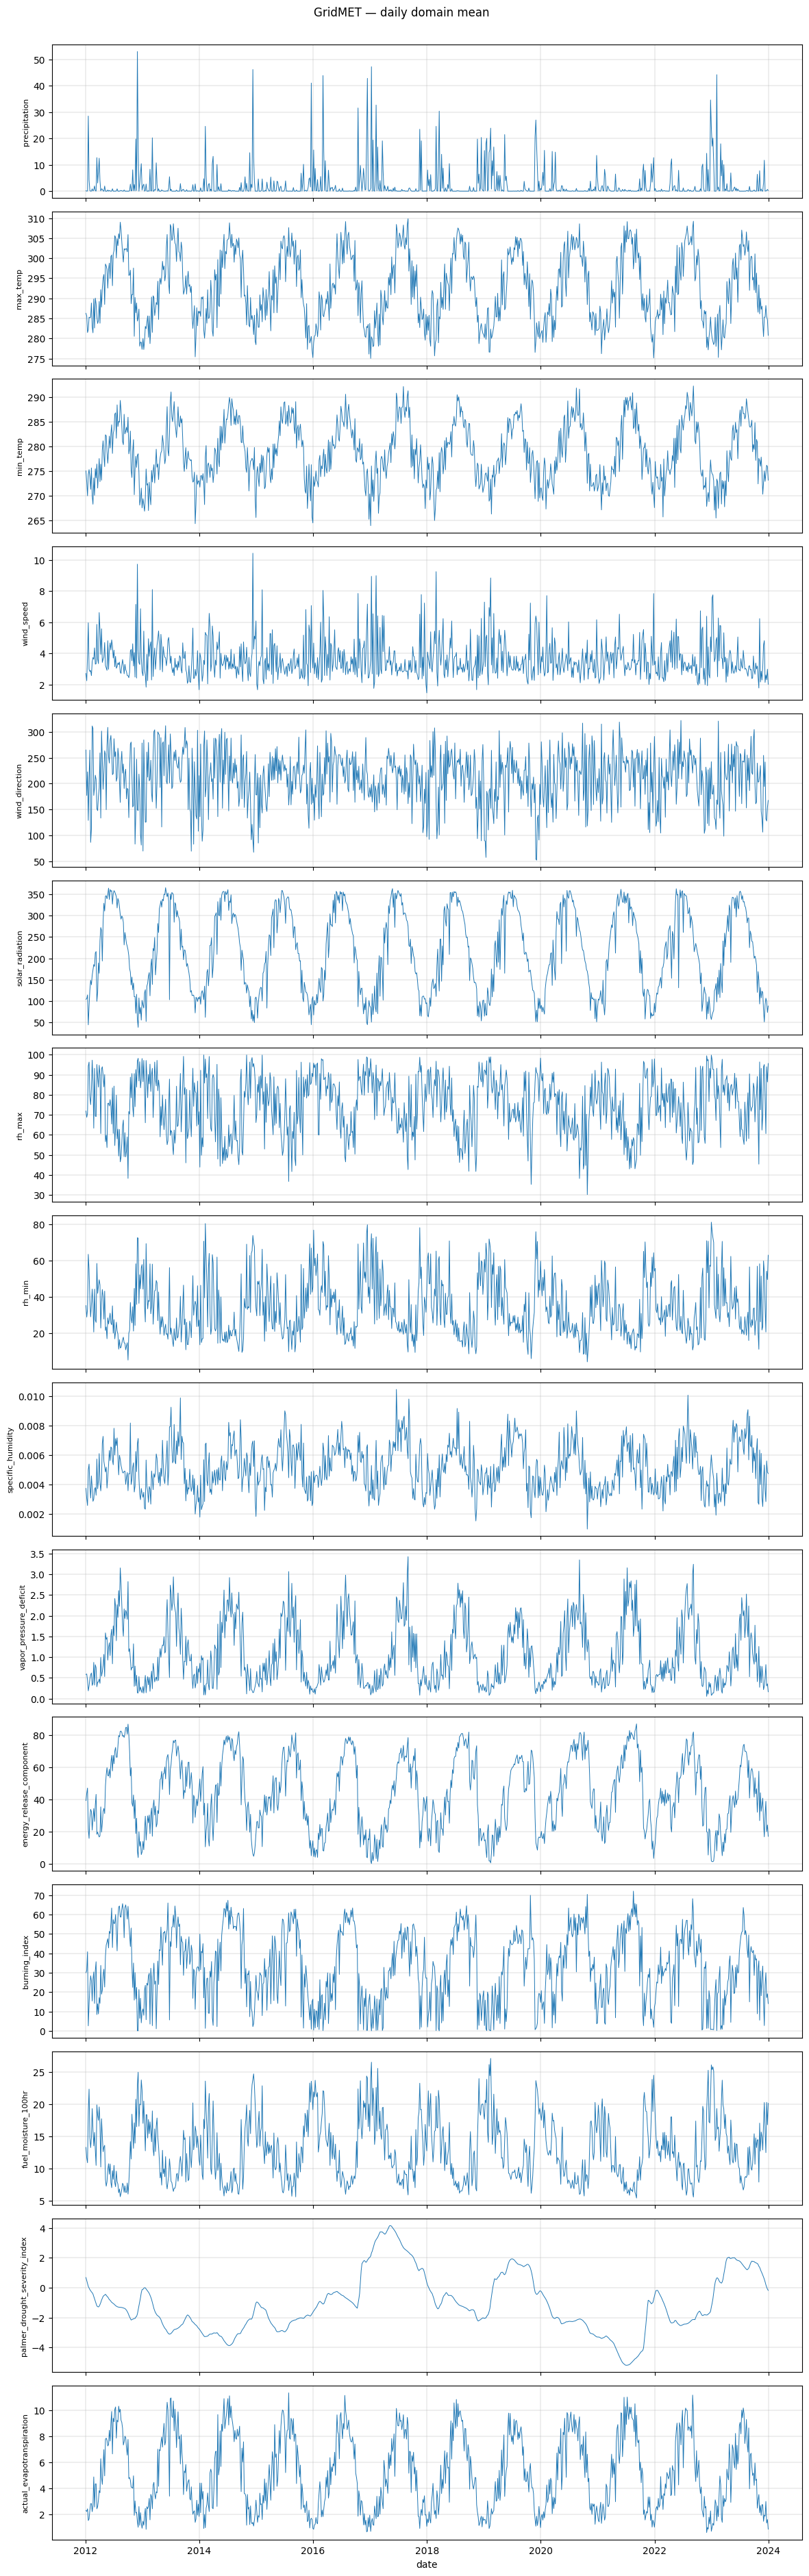

In [4]:
# Time series — domain-mean of each variable
numeric_vars = [c for c in df.columns if c not in ("time", "lat", "lon")]
ts = df.groupby("time")[numeric_vars].mean()

n = len(numeric_vars)
fig, axes = plt.subplots(n, 1, figsize=(12, 2.5 * n), sharex=True)
for ax, col in zip(axes, numeric_vars):
    ax.plot(ts.index, ts[col], linewidth=0.7)
    ax.set_ylabel(col, fontsize=8)
    ax.grid(True, linewidth=0.3)
axes[-1].set_xlabel("date")
fig.suptitle("GridMET — daily domain mean", y=1.002)
plt.tight_layout()
plt.show()


In [5]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

PARQUET = Path(__file__).resolve().parents[1] / "data_processed/fwi_indices.parquet" if "__file__" in dir() else Path("../data_processed/fwi_indices.parquet")

df = pd.read_parquet(PARQUET)
print(df.shape)
print(df.dtypes)
df.head()


(11832132, 9)
time    datetime64[ns]
lat            float64
lon            float64
ffmc           float64
dmc            float64
dc             float64
isi            float64
bui            float64
fwi            float64
dtype: object


,time,lat,lon,ffmc,dmc,dc,isi,bui,fwi
0,2012-01-05,36.983333,-122.183333,87.774991,7.331392,17.845001,11.093027,7.318899,9.655648
1,2012-01-05,36.983333,-122.141667,88.626973,7.509064,18.025001,11.241722,7.490060,9.858999
2,2012-01-05,36.983333,-122.100000,89.167658,7.624838,18.133002,10.700262,7.601464,9.516070
3,2012-01-05,36.983333,-122.058333,89.375832,7.682391,18.205001,9.887830,7.657349,8.923991
4,2012-01-05,36.983333,-122.016667,89.541222,7.724308,18.240998,9.081079,7.697642,8.307635


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

PARQUET = Path(__file__).resolve().parents[1] / "data_processed/land_cover.parquet" if "__file__" in dir() else Path("../data_processed/land_cover.parquet")

df = pd.read_parquet(PARQUET)
print(df.shape)
print(df.dtypes)
df.head()


(191413170, 5)
lat                 float32
lon                 float32
land_cover_class      uint8
land_cover_label     object
fuel_type             uint8
dtype: object


,lat,lon,land_cover_class,land_cover_label,fuel_type
0,40.954742,-124.134766,11,Open Water,98
1,40.954823,-124.134422,11,Open Water,98
2,40.954899,-124.134079,11,Open Water,98
3,40.954979,-124.133736,11,Open Water,98
4,40.955055,-124.133392,11,Open Water,98


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

PARQUET = Path(__file__).resolve().parents[1] / "data_processed/historical_ignition.parquet" if "__file__" in dir() else Path("../data_processed/historical_ignition.parquet")

df = pd.read_parquet(PARQUET)
print(df.shape)
print(df.dtypes)
df.head()


(11406, 4)
lat              float64
lon              float64
month              int32
ignition_prob    float64
dtype: object


,lat,lon,month,ignition_prob
0,37.0,-121.9,1,0.083333
1,37.0,-121.5,1,0.250000
2,37.0,-120.7,1,0.083333
3,37.0,-120.4,1,0.166667
4,37.0,-120.3,1,0.583333


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

PARQUET = Path(__file__).resolve().parents[1] / "data_processed/terrain.parquet" if "__file__" in dir() else Path("../data_processed/terrain.parquet")

df = pd.read_parquet(PARQUET)
print(df.shape)
print(df.dtypes)
df.head()


(32999313, 5)
lon          float64
lat          float64
elevation    float64
slope        float64
aspect       float64
dtype: object


,lon,lat,elevation,slope,aspect
0,-124.134583,42.009583,155.0,10.162176,38.573666
1,-124.133750,42.009583,147.0,9.393091,347.811384
2,-124.132917,42.009583,160.0,8.363267,331.630989
3,-124.132083,42.009583,157.0,11.815285,39.379108
4,-124.131250,42.009583,141.0,17.087572,39.513291


In [2]:
import rioxarray
import pandas as pd
import numpy as np

TIF = "vnp09ga_2012_01.tif"

rds = rioxarray.open_rasterio(TIF)

# Slice a 500x500 pixel window from the top-left
subset = rds.isel(x=slice(0, 500), y=slice(0, 500))

df = subset.to_dataframe(name="value").dropna(subset=["value"]).reset_index()
print(df.head())

   band         y           x  spatial_ref   value
0     1  42.03891 -121.921596            0  0.8596
1     1  42.03891 -121.917105            0  0.8596
2     1  42.03891 -121.912613            0  0.8596
3     1  42.03891 -121.908121            0  0.8543
4     1  42.03891 -121.903630            0  0.8542


78 bands, first 10: ['2012_01_19_20120119_I1', '2012_01_19_20120119_I2', '2012_01_19_20120119_I3', '2012_01_19_20120119_M11', '2012_01_19_20120119_NDVI', '2012_01_19_20120119_EVI', '2012_01_20_20120120_I1', '2012_01_20_20120120_I2', '2012_01_20_20120120_I3', '2012_01_20_20120120_M11']


/tmp/ipykernel_63384/1016832660.py:13: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


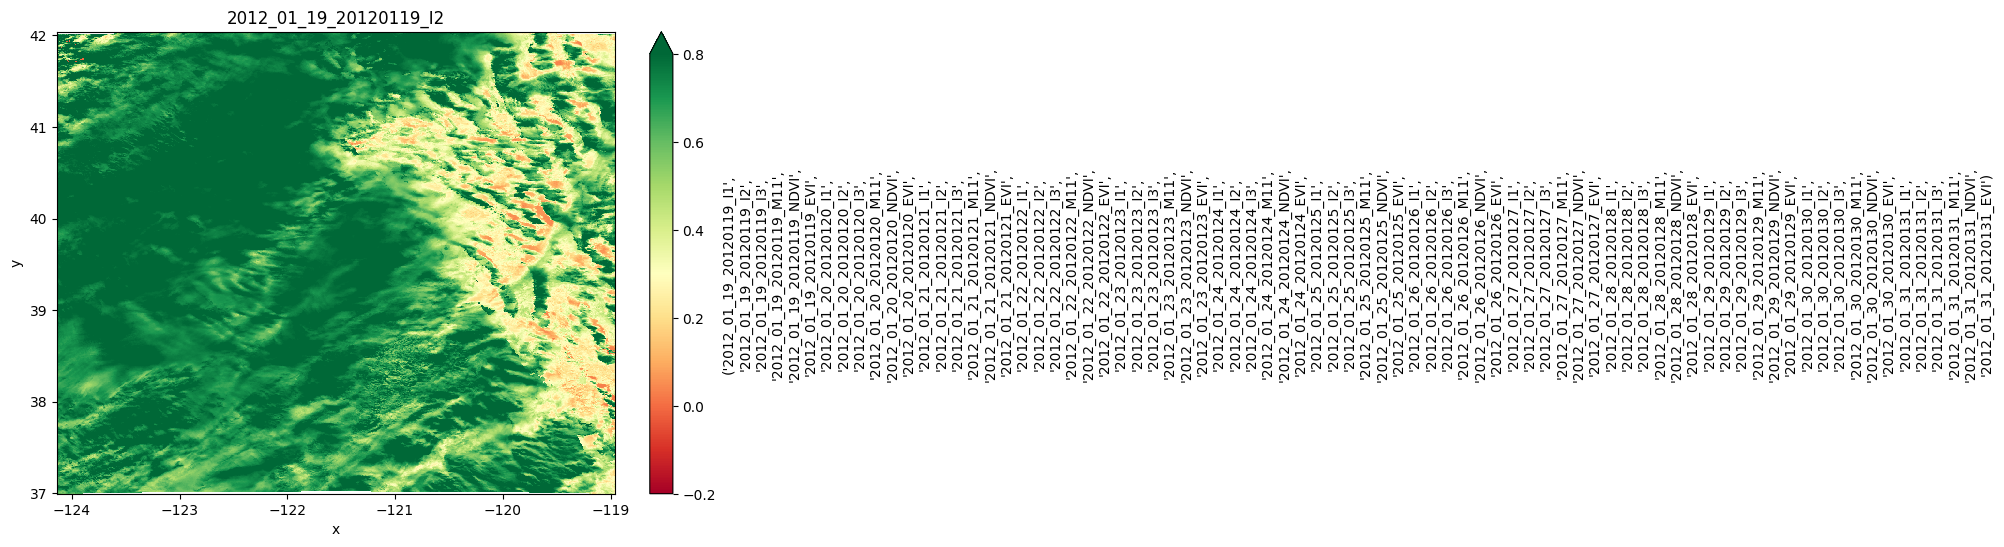

In [4]:
import matplotlib.pyplot as plt

band_names = list(rds.attrs.get("long_name", []))
print(f"{len(band_names)} bands, first 10: {band_names[:10]}")

# Plot NDVI for the first available date
ndvi_bands = [b for b in band_names if b.endswith("_I2")]
if ndvi_bands:
    idx = band_names.index(ndvi_bands[0])
    fig, ax = plt.subplots(figsize=(9, 6))
    rds.isel(band=idx).plot(ax=ax, cmap="RdYlGn", vmin=-0.2, vmax=0.8)
    ax.set_title(ndvi_bands[0])
    plt.tight_layout()
    plt.show()
